In [65]:
import numpy as np
from matplotlib import pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F

In [66]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)

cuda:0


In [67]:
import torchvision.datasets as datasets
mnist_trainset = datasets.MNIST(root=r'/home/xyphoes/Desktop/Projects/AIML - 2/Learning/Neural Networks/Projects/data', train=True, download=False, transform=None)
mnist_testset = datasets.MNIST(root=r'/home/xyphoes/Desktop/Projects/AIML - 2/Learning/Neural Networks/Projects/data', train=False, download=False, transform=None)

(xTrain, yTrain) = mnist_trainset.data.to(torch.float32), mnist_trainset.targets.to(torch.float32)
(xTest, yTest) = mnist_testset.data.to(torch.float32), mnist_testset.targets.to(torch.float32)
xTrain = xTrain / 255.0
xTest = xTest / 255.0
xTrain = xTrain.unsqueeze(1).to(device)  # shape: (N, 1, 28, 28)
xTest = xTest.unsqueeze(1).to(device)
yTest = yTest.long().to(device)
yTrain = yTrain.long().to(device)
xTrain.shape[0]

60000

In [ ]:
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.fl1 = nn.Linear(100,256)
        self.bn1 = nn.BatchNorm1d(256)
        self.fl2 = nn.Linear(256,512)
        self.bn2 = nn.BatchNorm1d(512)
        self.fl3 = nn.Linear(512,1024)
        self.bn3 = nn.BatchNorm1d(1024)
        self.out = nn.Linear(1024,28*28)
    
    def forward(self, X):
        out = F.relu(self.fl1(X))
        out = self.bn1(out)
        out = F.relu(self.fl2(out))
        out = self.bn2(out)
        out = F.relu(self.fl3(out))
        out = self.bn3(out)
        out = self.out(out)
        out = torch.reshape(out, (X.shape[0],1,28,28))
        return out

class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.fl1 = nn.Linear(28*28,512)
        self.fl2 = nn.Linear(512,256)
        self.out = nn.Linear(256,1)
    
    def forward(self,X):
        out = self.flatten(X)
        out = F.leaky_relu(self.fl1(out), negative_slope=0.2)
        out = F.leaky_relu(self.fl2(out), negative_slope=0.2)
        out = self.out(out)
        return out

In [ ]:
from torch.utils.data import TensorDataset, DataLoader
train_ds = TensorDataset(xTrain, yTrain)
batch_size = 64
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)

genModel = Generator().to(device)
discModel = Discriminator().to(device)
genOptim = torch.optim.Adam(genModel.parameters())
discOptim = torch.optim.Adam(discModel.parameters())
# We use binary cross entropy for both genLoss and discLoss.
genLoss = nn.BCEWithLogitsLoss()
discLoss = nn.BCEWithLogitsLoss()
n_epoch = 15

In [ ]:
genModel.train()
discModel.train()
for epoch in range(n_epoch):
    for xb,yb in train_loader:
        noise = torch.randn(xb.size(0),100).to(device)
        realLabels = torch.ones(xb.size(0),1,device=device)
        fakeLabels = torch.zeros(xb.size(0),1,device=device)
        fakeImages = genModel(noise)
        # disc is first evaluated on generated images and real images.
        discPreds_gen = discModel(fakeImages.detach())
        discPreds_real = discModel(xb)
        
        discOptim.zero_grad()
        # Since d_L must classify gen as fake, real as real, we eval loss with those.
        d_L = discLoss(discPreds_gen, fakeLabels) + discLoss(discPreds_real,realLabels)
        d_L.backward()
        discOptim.step()

        # Only after one model is backpropped, we will start backprop for second model.
        genOptim.zero_grad()
        fakeImages = genModel(noise)
        discPreds_gen = discModel(fakeImages)
        g_L = genLoss(discPreds_gen, realLabels) # Gen wants to have its images be classified as real.
        g_L.backward()
        genOptim.step()

    print(f"Gen Loss: {g_L} Disc Loss: {d_L}")
genModel.eval()
discModel.eval()

Gen Loss: 24.253374099731445 Disc Loss: 0.02898300066590309
Gen Loss: 17.090147018432617 Disc Loss: 0.17246952652931213
Gen Loss: 11.285311698913574 Disc Loss: 0.2819308340549469
Gen Loss: 9.801067352294922 Disc Loss: 0.2515738308429718
Gen Loss: 6.264404773712158 Disc Loss: 1.1746349334716797
Gen Loss: 1.6296758651733398 Disc Loss: 1.1284980773925781
Gen Loss: 7.11321496963501 Disc Loss: 1.1579029560089111
Gen Loss: 2.023236036300659 Disc Loss: 1.7974777221679688
Gen Loss: 6.008085250854492 Disc Loss: 1.1630785465240479
Gen Loss: 5.261223316192627 Disc Loss: 2.1173465251922607
Gen Loss: 4.7706618309021 Disc Loss: 3.1355273723602295
Gen Loss: 5.662056922912598 Disc Loss: 0.5775626301765442
Gen Loss: 3.156123638153076 Disc Loss: 1.4240132570266724
Gen Loss: 11.234199523925781 Disc Loss: 0.2524571716785431
Gen Loss: 2.6254122257232666 Disc Loss: 0.8599293231964111


Discriminator(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fl1): Linear(in_features=784, out_features=512, bias=True)
  (fl2): Linear(in_features=512, out_features=256, bias=True)
  (out): Linear(in_features=256, out_features=1, bias=True)
)

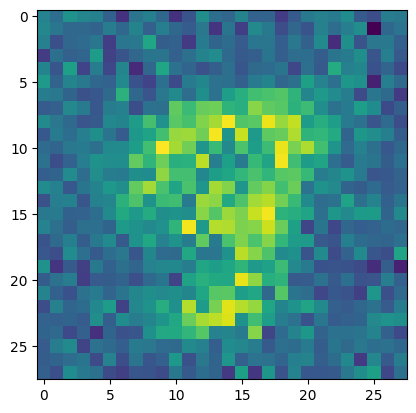

In [71]:
noise = torch.randn(2,1,100).to(device)
for n_ in noise:
    img = genModel(n_)
    img = img.squeeze(1)
    img = img[0]
    plt.imshow(img.cpu().detach().numpy())